In [21]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

In [22]:
data = pd.read_csv('/content/1D_Porosity.csv')
data.head()

,Depth,Nporosity
0,0.25,-1.37
1,0.50,-2.08
2,0.75,-1.67
3,1.00,-1.16
4,1.25,-0.24


In [23]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Depth      40 non-null     float64
 1   Nporosity  40 non-null     float64
dtypes: float64(2)
memory usage: 772.0 bytes


In [24]:
data.describe()

,Depth,Nporosity
count,40.000000,40.000000
mean,5.125000,0.022250
std,2.922613,0.992111
min,0.250000,-2.080000
25%,2.687500,-0.757500
50%,5.125000,0.140000
75%,7.562500,0.742500
max,10.000000,2.350000


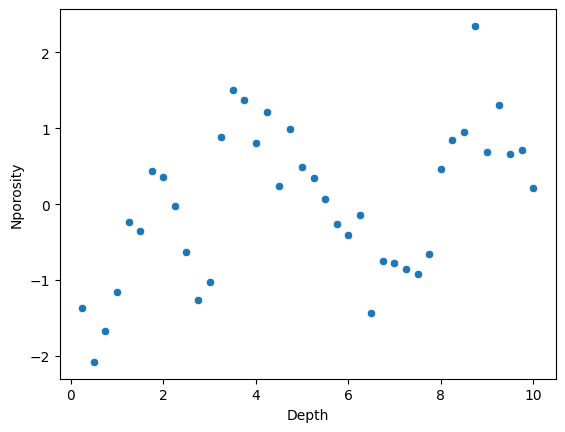

In [26]:
sns.scatterplot(x='Depth', y='Nporosity', data=data)
plt.show()

In [28]:
X = data[['Depth']]
y = data['Nporosity']

In [32]:
model = LinearRegression()
model.fit(X, y)

LinearRegression()

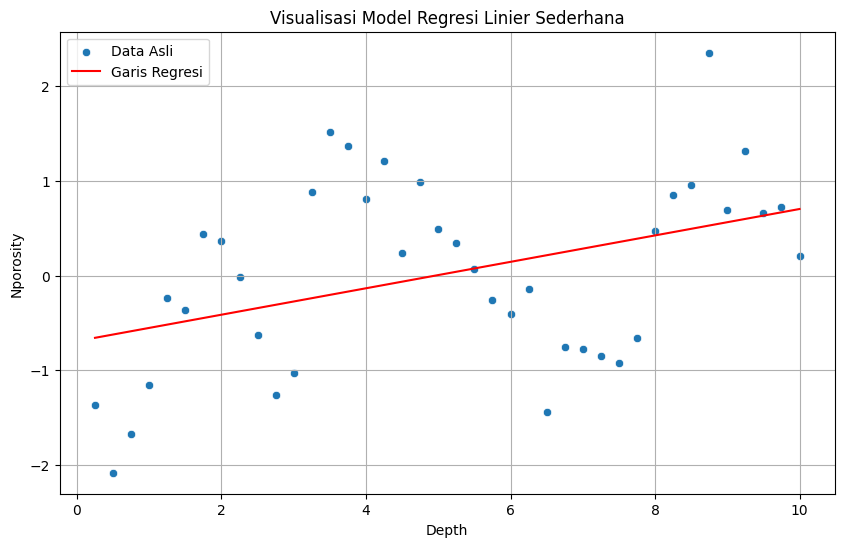

In [31]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Depth', y='Nporosity', data=data, label='Data Asli')
plt.plot(X, y_pred, color='red', label='Garis Regresi')
plt.title('Visualisasi Model Regresi Linier Sederhana')
plt.xlabel('Depth')
plt.ylabel('Nporosity')
plt.legend()
plt.grid(True)
plt.show()

Tujuan: Mencoba menghubungkan titik-titik data dengan satu garis lurus yang paling pas.

Tren: Garis merah menunjukkan bahwa secara umum, jika Kedalaman (Depth) bertambah, maka Porositas (Nporosity) juga cenderung naik.

Masalah (Underfitting): Karena datanya bergelombang (naik-turun), garis lurus ini terlalu kaku. Ia tidak bisa mengikuti lekukan data asli, sehingga tingkat kesalahannya (error) tinggi.

In [29]:
mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))


print('MAE:', mae)
print('MSE:',mse)
print('RMSE:',rmse)

MAE: 0.7399434333958724
MSE: 0.7979390086772984
RMSE: 0.8932743188278158


MAE (Mean Absolute Error): 0.7399

Rata-rata selisih mutlak antara prediksi dan data asli adalah sekitar 0.74. Semakin kecil angka ini, semakin baik.

MSE (Mean Squared Error): 0.7979

Rata-rata kuadrat error. Angka ini memberikan bobot lebih besar pada error yang besar.

RMSE (Root Mean Squared Error): 0.8932

Akar dari MSE. Ini adalah standar deviasi dari residu (error). Nilai 0.89 menunjukkan bahwa rata-rata prediksi meleset sekitar 0.89 unit dari nilai asli.

In [33]:
y_pred = model.predict(X)
print(y_pred)

[-0.65712195 -0.62228236 -0.58744278 -0.55260319 -0.5177636  -0.48292402
 -0.44808443 -0.41324484 -0.37840525 -0.34356567 -0.30872608 -0.27388649
 -0.2390469  -0.20420732 -0.16936773 -0.13452814 -0.09968856 -0.06484897
 -0.03000938  0.00483021  0.03966979  0.07450938  0.10934897  0.14418856
  0.17902814  0.21386773  0.24870732  0.2835469   0.31838649  0.35322608
  0.38806567  0.42290525  0.45774484  0.49258443  0.52742402  0.5622636
  0.59710319  0.63194278  0.66678236  0.70162195]


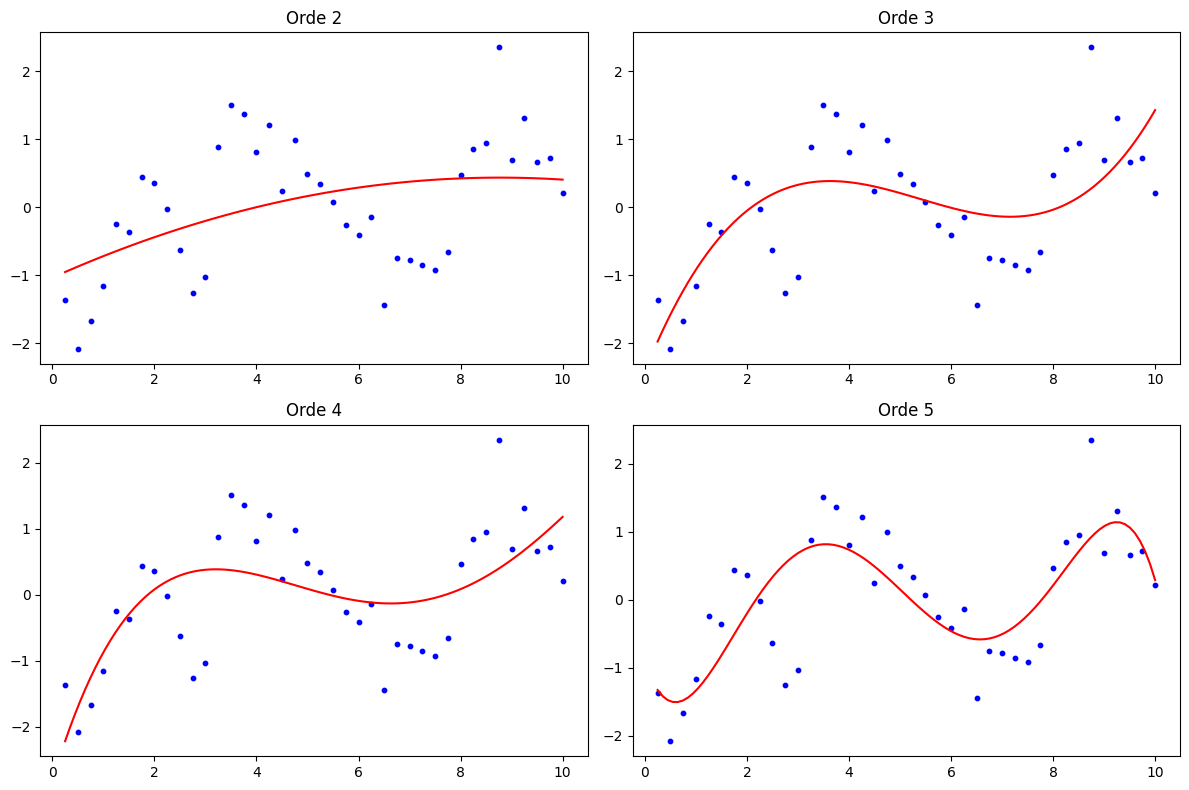

In [44]:

plt.figure(figsize=(12, 8))
X_plot = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)

for i, orde in enumerate([2, 3, 4, 5]):
    # Transform data jadi polinomial
    poly = PolynomialFeatures(degree=orde)
    X_poly = poly.fit_transform(X)

    # Training model
    model_p = LinearRegression().fit(X_poly, y)

    # Plotting
    plt.subplot(2, 2, i+1)
    plt.scatter(X, y, s=10, color='blue')
    plt.plot(X_plot, model_p.predict(poly.transform(X_plot)), color='red')
    plt.title(f"Orde {orde}")

plt.tight_layout()
plt.show()

Orde 2 (Kuadratik): Mulai melengkung, tapi hanya memiliki satu puncak. Belum cukup fleksibel.

Orde 3 (Kubik): Mulai mengikuti pola gelombang data (naik di awal, turun di tengah, naik lagi di akhir).

Orde 4 & 5: Garis merah semakin fleksibel dan semakin dekat dengan titik-titik data biru.

Orde 5 terlihat paling akurat dalam mengikuti lekukan data sensitif, namun harus hati-hati terhadap overfitting (terlalu memaksakan mengikuti setiap titik hingga kehilangan pola umum).